DATASET: Universal-LPC-spritesheet
Link: https://github.com/makrohn/Universal-LPC-spritesheet.git

In [1]:
import os
import sys
import argparse
from pathlib import Path
from collections import Counter
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
LPC_FRAME_W = 64
LPC_FRAME_H = 64

LPC_KNOWN_SIZES = {
    (832, 1344): "Full sheet (13 cols x 21 rows)",
    (832,  672): "Half sheet (13 cols x ~10 rows)",
    (576,  384): "Compact sheet (9 cols x 6 rows)",
}

LPC_ROW_ANIMS = {
    0:  "walk-up",    1:  "walk-left",   2:  "walk-down",  3:  "walk-right",
    4:  "run-up",     5:  "run-left",    6:  "run-down",   7:  "run-right",
    8:  "slash-up",   9:  "slash-left",  10: "slash-down", 11: "slash-right",
    12: "shoot-up",   13: "shoot-left",  14: "shoot-down", 15: "shoot-right",
    16: "hurt",
}


def classify_image(img: Image.Image, path: Path):
    w, h = img.size
    mode = img.mode

    # Convert to RGBA
    rgba = img.convert("RGBA")
    arr = np.array(rgba)

    alpha = arr[:, :, 3]
    total_px = w * h
    transparent_px = int((alpha == 0).sum())
    opaque_px = total_px - transparent_px
    alpha_coverage_pct = 100.0 * transparent_px / total_px if total_px else 0.0

    # Unique colours
    if total_px > 200000:
        flat = arr.reshape(-1, 4)
        idx = np.random.choice(len(flat), size=50000, replace=False)
        sample = flat[idx]
    else:
        sample = arr.reshape(-1, 4)
    unique_colors = len(set(map(tuple, sample.tolist())))

    is_sheet = (w % LPC_FRAME_W == 0) and (h % LPC_FRAME_H == 0) and (w > LPC_FRAME_W or h > LPC_FRAME_H)
    cols = w // LPC_FRAME_W if is_sheet else 1
    rows = h // LPC_FRAME_H if is_sheet else 1
    frame_count = cols * rows if is_sheet else 1

    known_label = LPC_KNOWN_SIZES.get((w, h), None)

    file_size_kb = path.stat().st_size / 1024

    return {
        "file":path.name,
        "path":str(path),
        "width":w,
        "height":h,
        "mode":mode,
        "file_size_kb":round(file_size_kb, 1),
        "is_sheet":is_sheet,
        "grid_cols":cols,
        "grid_rows":rows,
        "frame_count":frame_count,
        "known_sheet_label":known_label,
        "transparent_px":transparent_px,
        "opaque_px":opaque_px,
        "alpha_coverage_pct": round(alpha_coverage_pct, 1),
        "unique_colors":unique_colors,
    }


def print_record(rec: dict, verbose: bool = False):
    tag = "SHEET" if rec["is_sheet"] else "FRAME"
    known = f"  [{rec['known_sheet_label']}]" if rec["known_sheet_label"] else ""
    grid = f"{rec['grid_cols']}x{rec['grid_rows']} = {rec['frame_count']} frames" if rec["is_sheet"] else "single frame"
    print(f"[{tag}] {rec['file']}{known}")
    if verbose:
        print(f"size: {rec['width']}x{rec['height']} px  ({rec['file_size_kb']} KB)  mode={rec['mode']}")
        print(f"grid: {grid}")
        print(f"alpha: {rec['alpha_coverage_pct']}% transparent  ({rec['opaque_px']:,} opaque px)")
        print(f"colors: ~{rec['unique_colors']:,} unique RGBA values")


def print_summary(records: list[dict]):
    n = len(records)

    sheets = [r for r in records if r["is_sheet"]]
    singles = [r for r in records if not r["is_sheet"]]
    total_kb = sum(r["file_size_kb"] for r in records)
    total_frames = sum(r["frame_count"] for r in records)

    widths  = [r["width"]  for r in records]
    heights = [r["height"] for r in records]
    alphas  = [r["alpha_coverage_pct"] for r in records]
    colors  = [r["unique_colors"] for r in records]

    print(f"\n{'─'*60}")
    print(f"Total images    : {n}  ({len(sheets)} sheets, {len(singles)} single frames)")
    print(f"Total disk size : {total_kb/1024:.2f} MB")
    print(f"Total frames    : {total_frames}")
    print()
    print(f"Dimensions (WxH)")
    print(f"min: {min(widths)}x{min(heights)}")
    print(f"max: {max(widths)}x{max(heights)}")
    print(f"mean: {sum(widths)//n}x{sum(heights)//n}")
    print()
    print(f"Alpha coverage")
    print(f"min: {min(alphas)}%")
    print(f"max: {max(alphas)}%")
    print(f"mean: {sum(alphas)/n:.1f}%")
    print()
    print(f"Unique colours (RGBA, sampled)")
    print(f"min: {min(colors):,}")
    print(f"max: {max(colors):,}")
    print(f"mean: {int(sum(colors)/n):,}")

    if sheets:
        frame_counts = [r["frame_count"] for r in sheets]
        dim_counter = Counter(f"{r['width']}x{r['height']}" for r in sheets)
        print()
        print(f"Sheet frame counts")
        print(f"min: {min(frame_counts)}")
        print(f"max: {max(frame_counts)}")
        print(f"mean: {int(sum(frame_counts)/len(sheets))}")
        print(f"Most common sheet dimensions:")
        for dim, count in dim_counter.most_common(5):
            label = ""
            for (kw, kh), desc in LPC_KNOWN_SIZES.items():
                if dim == f"{kw} x {kh}":
                    label = f"[{desc}]"
            print(f"{dim} x {count} file(s){label}")

    print(f"{'─'*60}")


def save_plots(records: list[dict], out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)

    # Dimension scatter
    fig, ax = plt.subplots(figsize=(7, 5))
    for r in records:
        marker = "s"
        ax.scatter(r["width"], r["height"], marker=marker, alpha=0.8, s=60)
    ax.set_xlabel("Width (px)")
    ax.set_ylabel("Height (px)")
    ax.set_title("Image Dimensions")
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.tight_layout()
    fig.savefig(out_dir / "dimensions.png", dpi=120)
    fig.show()
    plt.close(fig)

    # Alpha coverage histogram
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist([r["alpha_coverage_pct"] for r in records], bins=20, color="#4a90d9", edgecolor="white")
    ax.set_xlabel("% Transparent Pixels")
    ax.set_ylabel("Count")
    ax.set_title("Alpha Coverage Distribution")
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")
    fig.tight_layout()
    fig.savefig(out_dir / "alpha_coverage.png", dpi=120)
    fig.show()
    plt.close(fig)

    # Frame count distribution
    sheets = [r for r in records if r["is_sheet"]]
    if sheets:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist([r["frame_count"] for r in sheets], bins=15, color="#e07b39", edgecolor="white")
        ax.set_xlabel("Frame Count per Sheet")
        ax.set_ylabel("Count")
        ax.set_title("Frames per Sprite Sheet")
        ax.grid(True, linestyle="--", alpha=0.4, axis="y")
        fig.tight_layout()
        fig.show()
        fig.savefig(out_dir / "frame_counts.png", dpi=120)





────────────────────────────────────────────────────────────
Total images    : 2755  (2755 sheets, 0 single frames)
Total disk size : 24.44 MB
Total frames    : 671839

Dimensions (WxH)
min: 128x128
max: 1536x1344
mean: 757x1210

Alpha coverage (% transparent pixels)
min: 86.5%
max: 100.0%
mean: 96.5%

Unique colours (RGBA, sampled)
min: 1
max: 104
mean: 6

Sheet frame counts
min: 4
max: 288
mean: 243
Most common sheet dimensions:
832x1344 x 2447 file(s)
128x128 x 296 file(s)
1152x768 x 8 file(s)
1536x768 x 3 file(s)
512x256 x 1 file(s)
────────────────────────────────────────────────────────────
hair 1810 PNGs dims: 832x1344
_build 313 PNGs dims: 128x128, 512x256, 832x1344
facial 300 PNGs dims: 832x1344
body 106 PNGs dims: 832x1344
torso 70 PNGs dims: 832x1344
accessories 27 PNGs dims: 832x1344
weapons 27 PNGs dims: 1152x768, 1536x768, 832x1344
behind_body 23 PNGs dims: 832x1344
head 19 PNGs dims: 832x1344
belt 15 PNGs dims: 832x1344
feet 15 PNGs dims: 832x1344
legs 14 PNGs dims: 832

C:\Users\jwang\AppData\Local\Temp\ipykernel_13492\2632429751.py:148: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\jwang\AppData\Local\Temp\ipykernel_13492\2632429751.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\jwang\AppData\Local\Temp\ipykernel_13492\2632429751.py:173: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


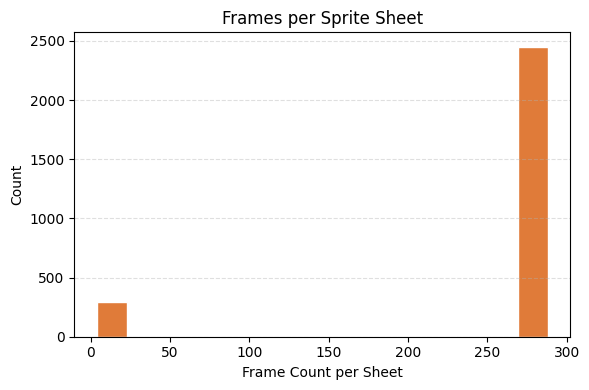

In [3]:
data_dir = Path(".\\Universal-LPC-spritesheet")

CATEGORIES = [
    "body", "hair", "torso", "legs", "feet", "head",
    "hands", "belt", "accessories", "behind_body",
    "weapons", "facial", "formal_male_no_th-sh", "_build",
]

def get_category(path: Path, base: Path) -> str:
    try:
        rel = path.relative_to(base)
        return rel.parts[0] if len(rel.parts) > 1 else "root"
    except ValueError:
        return "unknown"


png_files = sorted(data_dir.rglob("*.png"))

records = []
for path in png_files:
    try:
        img = Image.open(path)
        rec = classify_image(img, path)
        rec["category"] = get_category(path, data_dir)
        records.append(rec)
    except Exception as e:
        print(e)

print_summary(records)

cat_counts = Counter(r["category"] for r in records)
for cat, cnt in sorted(cat_counts.items(), key=lambda x: -x[1]):
    sizes = set(f"{r['width']}x{r['height']}" for r in records if r["category"] == cat)
    print(f"{cat} {cnt} PNGs dims: {', '.join(sorted(sizes))}")

out_dir = Path(".\\EDA_output")
save_plots(records, out_dir)

## Example Image:

(np.float64(-0.5), np.float64(831.5), np.float64(1343.5), np.float64(-0.5))

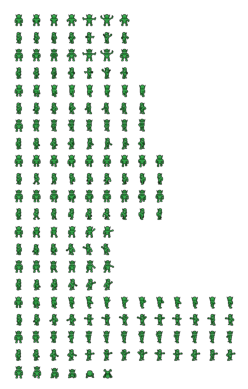

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread('.\\Universal-LPC-spritesheet\\body\male\orc.png')
plt.imshow(img)
plt.axis(False)


### NEXT STEP AFTER EDA:

1. Generate a more diverse dataset with the options from the LPC dataset, make sure that the final dataset contains a variety of characters styles and clothing.
2. Use the resulting dataset to train a generative model that can "outpaint" the entire sprite sheet from the first frame.  